In [1]:
# #  Customer Churn Prediction using Machine Learning

# ##  Objective
# Predict whether a customer will leave (Churn) or stay using Machine Learning.

# ###  Dataset
# Telco Customer Churn Dataset (Kaggle)

# ###  Algorithm
# Random Forest Classifier

# ###  Libraries
# Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

# ###  Goal
# Build a model that predicts customer churn and identify the most important factors affecting customer retention.

In [6]:
# Import Libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

In [7]:
# Load Dataset
# Load Dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Dataset Overview
print("="*60)

print("Dataset Shape :",df.shape)

print("="*60)

print("\nColumns\n")

print(df.columns.tolist())

print("\nData Types\n")

print(df.dtypes)

print("\nMissing Values\n")

print(df.isnull().sum())

print("\nDuplicate Rows :",df.duplicated().sum())

print("\nStatistical Summary\n")

display(df.describe(include="all"))

Dataset Shape : (7043, 21)

Columns

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values

custome

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [9]:
# Data Cleaning
# Remove Customer ID

df.drop("customerID",axis=1,inplace=True)

# Convert TotalCharges to numeric

df["TotalCharges"]=pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing values

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

print("Remaining Missing Values\n")

print(df.isnull().sum())

Remaining Missing Values

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
# Feature Engineering
# Average monthly spending

df["AvgMonthlySpend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

# Total Charge per Monthly Charge

df["ChargePerMonth"] = (
    df["TotalCharges"] /
    (df["MonthlyCharges"] + 1)
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,ChargePerMonth
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.925000,0.967585
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,53.985714,32.605695
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.050000,1.971741
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.016304,42.511547
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.550000,2.115063


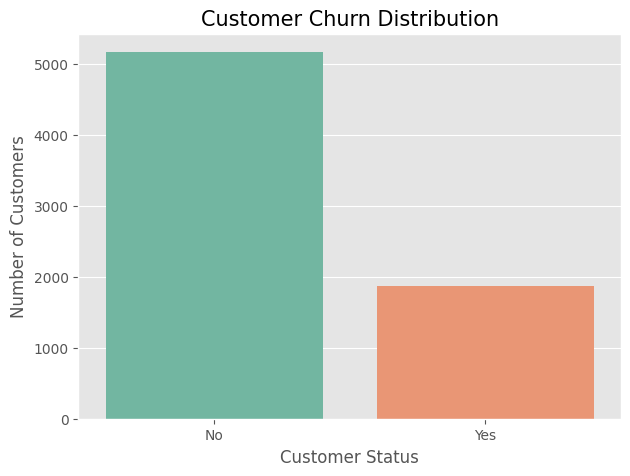

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [11]:
#Customer Churn Count
plt.figure(figsize=(7,5))

sns.countplot(
    x="Churn",
    data=df,
    palette="Set2"
)

plt.title("Customer Churn Distribution",fontsize=15)

plt.xlabel("Customer Status")

plt.ylabel("Number of Customers")

plt.show()

print(df["Churn"].value_counts())

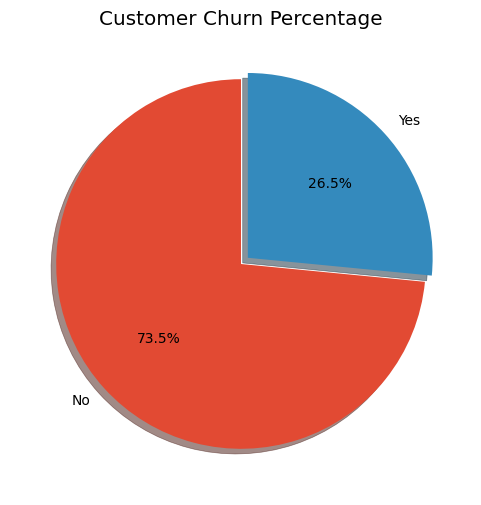

In [12]:
# Customer Churn Percentage
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    shadow=True,
    startangle=90,
    explode=[0,0.05]
)

plt.ylabel("")

plt.title("Customer Churn Percentage")

plt.show()

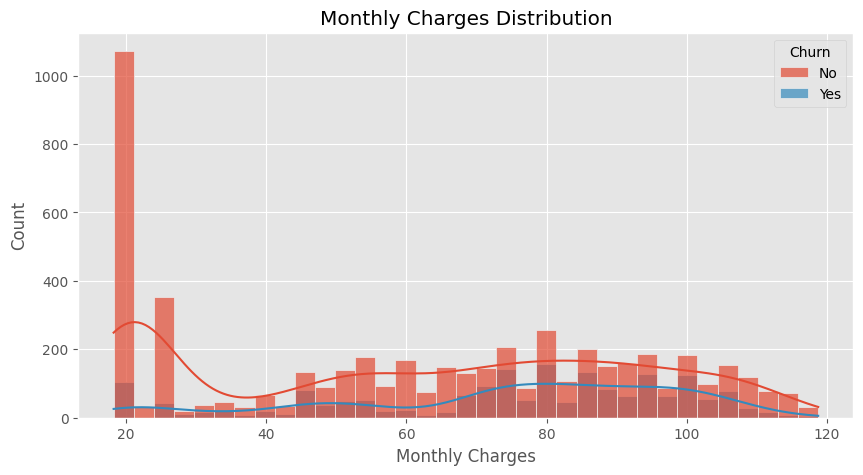

In [13]:
# Monthly Charges Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=35,
    kde=True,
    alpha=0.7
)

plt.title("Monthly Charges Distribution")

plt.xlabel("Monthly Charges")

plt.show()

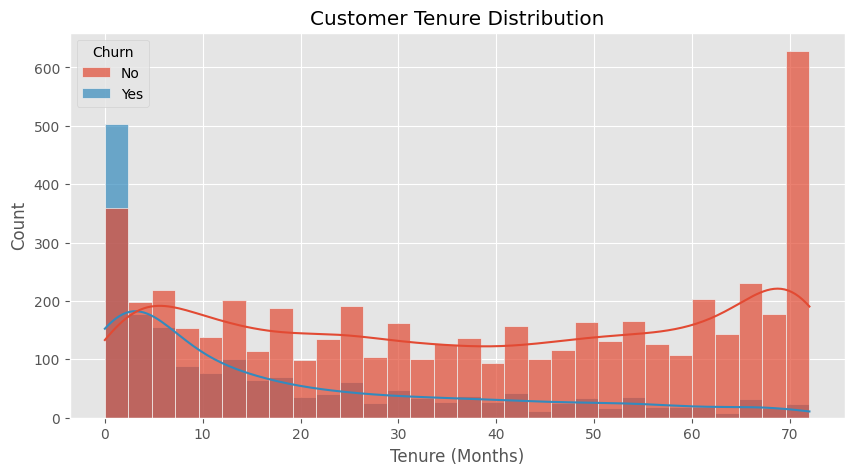

In [14]:
# Customer Tenure Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    alpha=0.7
)

plt.title("Customer Tenure Distribution")

plt.xlabel("Tenure (Months)")

plt.show()

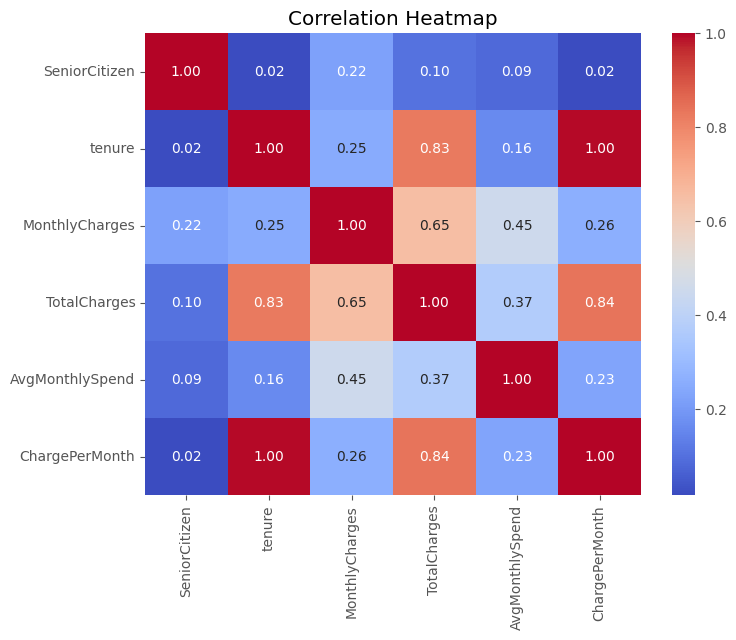

In [15]:
# Correlation Heatmap
# Correlation Heatmap (Numerical Features)

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

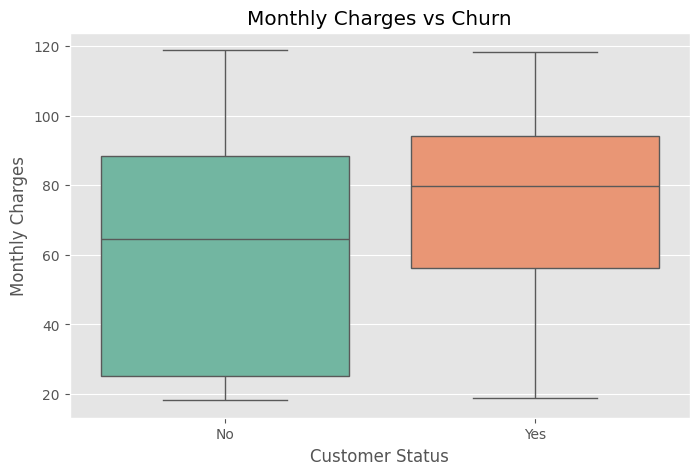

In [16]:
# Boxplot (Monthly Charges vs Churn)
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette="Set2"
)

plt.title("Monthly Charges vs Churn")

plt.xlabel("Customer Status")

plt.ylabel("Monthly Charges")

plt.show()

In [17]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in df.columns:

    if df[column].dtype == "object":

        df[column] = encoder.fit_transform(df[column])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,ChargePerMonth
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,1,2,29.85,29.85,0,14.925000,0.967585
1,1,0,0,0,34,1,0,0,2,0,...,0,0,1,0,3,56.95,1889.50,0,53.985714,32.605695
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,1,3,53.85,108.15,1,36.050000,1.971741
3,1,0,0,0,45,0,1,0,2,0,...,0,0,1,0,0,42.30,1840.75,0,40.016304,42.511547
4,0,0,0,0,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,1,50.550000,2.115063


In [18]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X = df.drop("Churn",axis=1)

y = df["Churn"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :",X_train.shape)

print("Testing Shape :",X_test.shape)

Training Shape : (5634, 21)
Testing Shape : (1409, 21)


In [19]:
# Train Random Forest Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [20]:
# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

print("Accuracy :",round(accuracy*100,2),"%")

print("Precision :",round(precision*100,2),"%")

print("Recall :",round(recall*100,2),"%")

print("F1 Score :",round(f1*100,2),"%")

print("\nClassification Report\n")

print(classification_report(y_test,y_pred))

Accuracy : 78.28 %
Precision : 61.72 %
Recall : 47.86 %
F1 Score : 53.92 %

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



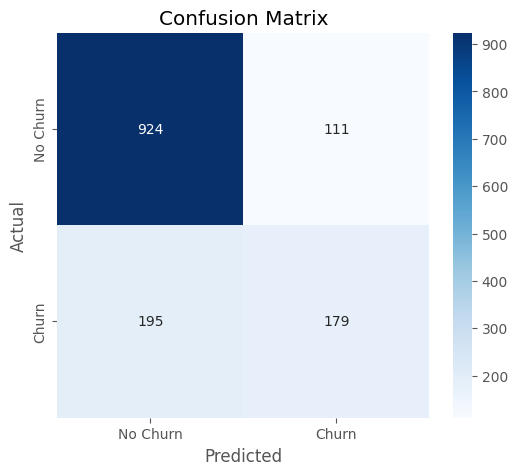

In [21]:
# Confusion Matrix Heatmap
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

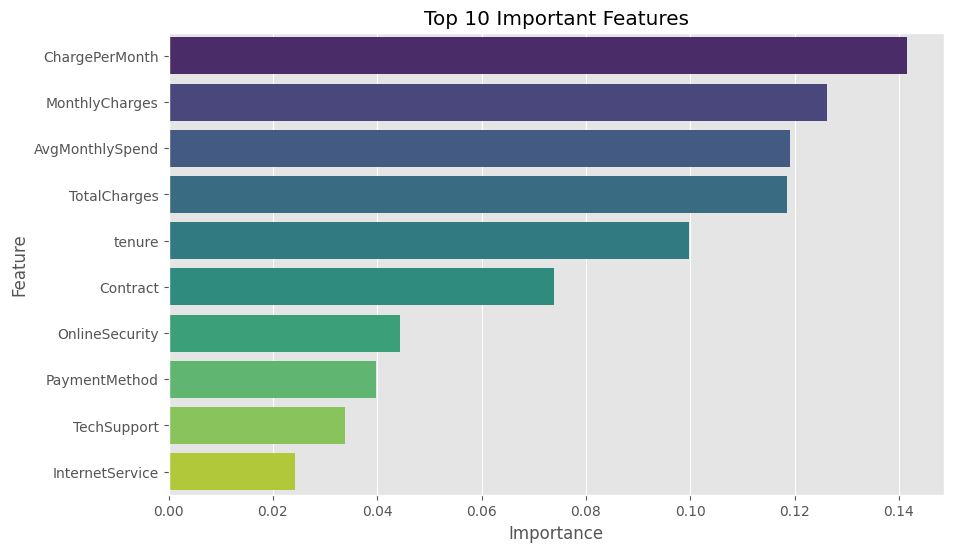

In [22]:
# Feature Importance
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features")

plt.show()

In [23]:
# Predict New Customer
sample = X.iloc[[0]]

prediction = model.predict(sample)

if prediction[0] == 1:

    print("Prediction : Customer will Churn")

else:

    print("Prediction : Customer will Stay")

Prediction : Customer will Stay


In [24]:
# Save Model
import joblib

joblib.dump(
    model,
    "customer_churn_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
